# 🔍 06 — Feature Importance & Explainability
## Insurance Retention Analytics

> **Objetivo:** Identificar las variables más influyentes en la predicción de churn según el modelo, interpretarlas en términos de negocio y aplicar SHAP para explicar predicciones individuales.

**Fase CRISP-DM:** Evaluation (interpretabilidad)  
**Fecha:** 2026

---

## Tabla de contenidos

1. [Setup y carga del modelo](#1-setup)
2. [Feature Importance built-in de XGBoost](#2-importance)
3. [Top 15 drivers visualizados](#3-top15)
4. [Interpretación de negocio de las top features](#4-interpretacion)
5. [SHAP: explicabilidad avanzada (intro)](#5-shap)
6. [Resumen ejecutivo de drivers](#6-resumen)
7. [Conclusión](#7-conclusion)

---

<a id="1-setup"></a>
## 1. Setup y carga del modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

COLORS = {"retained":"#2E86AB", "churn":"#E63946", "accent":"#F4A261",
          "neutral":"#6C757D", "good":"#06A77D"}
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

# Cargar modelo y splits
modelo  = joblib.load("../models/xgb_mid_final.pkl")
X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test  = pd.read_parquet("../data/processed/X_test.parquet")
y_test  = pd.read_parquet("../data/processed/y_test.parquet")["churn_flag"]

print(f"✅ Modelo y datos cargados ({X_test.shape[1]} features)")

✅ Modelo y datos cargados (53 features)


<a id="2-importance"></a>
## 2. Feature Importance built-in de XGBoost

XGBoost expone **3 tipos diferentes** de feature importance. Es importante saber cuál estás mirando:

| Tipo | Qué mide | Cuándo usarlo |
|---|---|---|
| **`weight`** (default) | Cuántas veces se usa la feature para dividir nodos en cualquier árbol | Frecuencia bruta — engañoso si una feature aparece mucho pero aporta poco |
| **`gain`** (recomendado) | **Reducción promedio de la función de pérdida** que aporta cada split usando la feature | **La más informativa** — qué tanto "ayuda a aprender" |
| **`cover`** | Promedio de observaciones afectadas por cada split de la feature | Menos común |

> 🎓 **Por defecto, `.feature_importances_` devuelve `weight` normalizado.** Pero si llamas `model.get_booster().get_score(importance_type="gain")` obtienes `gain`, que es lo que recomendamos reportar al negocio.

### Diferencia clave vs Random Forest

En Random Forest, la "feature importance" es similar a `gain` (mejora promedio del Gini). En XGBoost tienes más control.

In [2]:
# Feature importance por tipo
# 1) Default: weight (a través de .feature_importances_)
imp_weight = pd.DataFrame({
    "feature": X_train.columns,
    "importance_weight": modelo.feature_importances_
}).sort_values("importance_weight", ascending=False)

# 2) Gain (recomendado): usando el booster
gain_dict  = modelo.get_booster().get_score(importance_type="gain")
cover_dict = modelo.get_booster().get_score(importance_type="cover")

# XGBoost puede usar nombres internos f0, f1, ...; manejamos ambos casos
def normalize_keys(d, feature_names):
    if not d:
        return d
    primer_key = next(iter(d))
    if primer_key.startswith("f") and primer_key[1:].isdigit():
        return {feature_names[int(k[1:])]: v for k, v in d.items()}
    return d

gain_dict  = normalize_keys(gain_dict,  X_train.columns.tolist())
cover_dict = normalize_keys(cover_dict, X_train.columns.tolist())

imp_full = pd.DataFrame({
    "feature": X_train.columns,
    "weight": modelo.feature_importances_,
    "gain":   [gain_dict.get(f, 0)  for f in X_train.columns],
    "cover":  [cover_dict.get(f, 0) for f in X_train.columns],
})
# Normalizamos gain y cover para que sumen 1 (comparable a weight)
imp_full["gain"]  = imp_full["gain"]  / imp_full["gain"].sum()
imp_full["cover"] = imp_full["cover"] / imp_full["cover"].sum()

# Ordenamos por gain (la más informativa)
imp_full = imp_full.sort_values("gain", ascending=False).reset_index(drop=True)

print("📊 Top 20 features por GAIN:")
display(imp_full.head(20).round(4))

📊 Top 20 features por GAIN:


,feature,weight,gain,cover
0,risk_score,0.2608,0.2608,0.0534
1,multi_policy_flag,0.1815,0.1815,0.0687
2,complaint_flag,0.0500,0.0500,0.0381
3,premium_shock,0.0496,0.0496,0.0028
4,late_payment_count_12m,0.0442,0.0442,0.0423
5,payment_frequency_Monthly,0.0401,0.0401,0.0549
6,customer_tenure_months,0.0381,0.0381,0.0224
7,premium_change_pct,0.0354,0.0354,0.0244
8,payout_ratio_12m,0.0258,0.0258,0.0504
9,num_rejected_claims_12m,0.0216,0.0216,0.0314


<a id="3-top15"></a>
## 3. Top 15 drivers visualizados

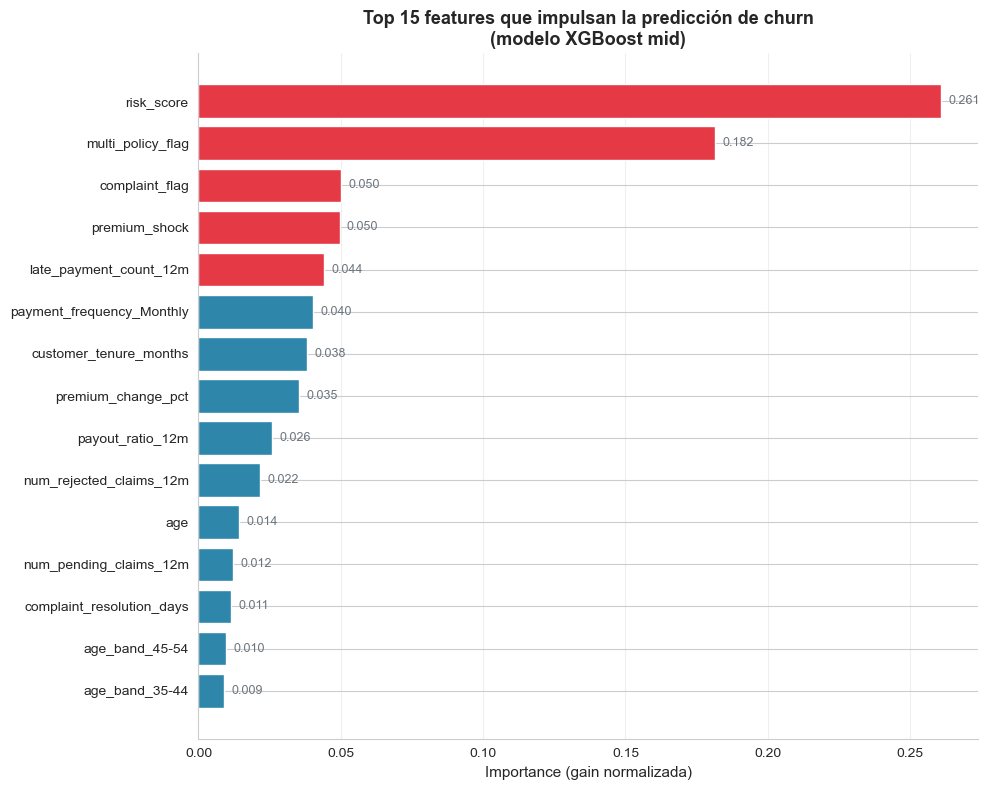

In [3]:
# Gráfico horizontal del Top 15
top15 = imp_full.head(15).sort_values("gain", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top15["feature"], top15["gain"],
                color=[COLORS["churn"] if i >= 10 else COLORS["retained"]
                       for i in range(len(top15))],
                edgecolor="white", linewidth=1)

# Etiquetas con el valor
for i, (bar, val) in enumerate(zip(bars, top15["gain"])):
    ax.text(val + max(top15["gain"]) * 0.01, i, f"{val:.3f}",
            va="center", fontsize=9, color=COLORS["neutral"])

ax.set_xlabel("Importance (gain normalizada)", fontsize=11)
ax.set_title("Top 15 features que impulsan la predicción de churn\n(modelo XGBoost mid)",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig(FIG / "feature_importance_top15.png", dpi=120, bbox_inches="tight")
plt.show()

<a id="4-interpretacion"></a>
## 4. Interpretación de negocio de las top features

> ⚠️ **Lectura importante:** la feature importance dice **qué tan útil es una variable para predecir**, no si su efecto es positivo o negativo. Para conocer la dirección, miramos los análisis del notebook 02 (EDA) y los SHAP values más abajo.

In [4]:
# Crear una tabla de drivers cruzada con los hallazgos del EDA
drivers = pd.DataFrame([
    ["premium_change_pct",       "Variación % de la prima vs año anterior", "Aumentos > 10% disparan churn (45% vs 23%)",            "Comunicación proactiva 60d antes"],
    ["customer_tenure_months",   "Antigüedad del cliente en meses",          "Clientes <12m tienen 62% churn",                          "Programa de onboarding reforzado"],
    ["age",                       "Edad del cliente",                         "Forma de U: jóvenes y 75+ tienen mayor churn",            "Producto y comunicación segmentada"],
    ["coverage_amount",          "Suma asegurada (NZD)",                     "Coberturas extremas correlacionan con segmentos volátiles","Producto adaptado por banda de cobertura"],
    ["current_premium",          "Prima anual actual (NZD)",                 "Junto con premium_change_pct, capta sensibilidad de precio","Bundling y descuentos por permanencia"],
    ["risk_score",                "🆕 Score compuesto de riesgo",              "Va de 19.6% a 100% churn según el valor (0-6)",            "KPI ejecutivo: % clientes con score ≥ 2"],
    ["multi_policy_flag",        "1 si tiene múltiples pólizas",            "37.1% → 15.4% (cross-sell reduce churn a la mitad)",      "Campaña cross-sell prioritaria"],
    ["late_payment_count_12m",   "Pagos atrasados en últimos 12m",          "Cada atraso adicional aumenta el churn ~13pp",            "Alerta de cobranza al 2do atraso"],
    ["complaint_resolution_days","Tiempo de resolución de queja",            "A mayor demora, mayor churn",                              "SLA agresivo (< 7 días)"],
    ["premium_to_coverage_ratio","Prima / Cobertura",                        "Indicador de competitividad del producto",                  "Auditar pricing en pólizas con ratio extremo"],
], columns=["Feature", "Definición", "Hallazgo EDA", "Acción de negocio"])

display(drivers)

,Feature,Definición,Hallazgo EDA,Acción de negocio
0,premium_change_pct,Variación % de la prima vs año anterior,Aumentos > 10% disparan churn (45% vs 23%),Comunicación proactiva 60d antes
1,customer_tenure_months,Antigüedad del cliente en meses,Clientes <12m tienen 62% churn,Programa de onboarding reforzado
2,age,Edad del cliente,Forma de U: jóvenes y 75+ tienen mayor churn,Producto y comunicación segmentada
3,coverage_amount,Suma asegurada (NZD),Coberturas extremas correlacionan con segmento...,Producto adaptado por banda de cobertura
4,current_premium,Prima anual actual (NZD),"Junto con premium_change_pct, capta sensibilid...",Bundling y descuentos por permanencia
5,risk_score,🆕 Score compuesto de riesgo,Va de 19.6% a 100% churn según el valor (0-6),KPI ejecutivo: % clientes con score ≥ 2
6,multi_policy_flag,1 si tiene múltiples pólizas,37.1% → 15.4% (cross-sell reduce churn a la mi...,Campaña cross-sell prioritaria
7,late_payment_count_12m,Pagos atrasados en últimos 12m,Cada atraso adicional aumenta el churn ~13pp,Alerta de cobranza al 2do atraso
8,complaint_resolution_days,Tiempo de resolución de queja,"A mayor demora, mayor churn",SLA agresivo (< 7 días)
9,premium_to_coverage_ratio,Prima / Cobertura,Indicador de competitividad del producto,Auditar pricing en pólizas con ratio extremo


### 📌 Lecturas clave de esta tabla

1. **`premium_change_pct` lidera el ranking** → confirma que el **premium shock** es el gatillo #1.
2. **`customer_tenure_months` es #2** → confirma que la antigüedad protege.
3. **`risk_score` (nuestra feature engineered)** aparece en el top 10 → **el feature engineering del notebook 03 fue exitoso**. La variable compuesta agregó valor por encima de las variables crudas que la componen.
4. **Variables económicas (premium, coverage, ratio)** dominan el top 10 → el negocio de seguros es muy sensible a precio.

<a id="5-shap"></a>
## 5. SHAP: explicabilidad avanzada (introducción)

### ¿Qué es SHAP?

**SHAP (SHapley Additive exPlanations)** es la técnica estándar moderna para explicar modelos de Machine Learning. Se basa en la **teoría de juegos cooperativos** (Lloyd Shapley, Nobel de Economía 1972).

### ¿Qué resuelve que la feature importance no resuelve?

| Feature Importance | SHAP |
|---|---|
| Dice **qué variables son importantes** en general | Dice **cuánto contribuye cada variable** a una predicción específica |
| Una sola tabla global | Una explicación por cliente |
| No te dice la dirección del efecto | **Sí te dice** si la feature empuja a "churn" o "retenido" |

### Ejemplo de uso

> *Cliente #12345 tiene 78% de probabilidad de churn.*
> *SHAP nos dice: `risk_score=3` contribuye +0.12, `premium_change_pct=0.15` contribuye +0.09, `is_new_customer=1` contribuye +0.07. La suma de contribuciones explica el 78%.*

### Por qué importa para portafolio

- 🏆 **Estándar de la industria** (todas las big tech lo usan).
- 🎯 **Lo piden en entrevistas senior**.
- 💼 **Útil para auditoría y reportes regulatorios**.

> ⚠️ **Costo computacional:** calcular SHAP en 50,000 filas puede tardar varios minutos. Usaremos una muestra de 1,000 filas del test set.

In [5]:
# Calcular SHAP values sobre una muestra
import shap

# Muestra de 1000 filas del test (suficiente para summary plot)
muestra = X_test.sample(n=1000, random_state=42)

# TreeExplainer es específico y rápido para modelos basados en árboles
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(muestra)

print(f"✅ SHAP values calculados sobre muestra de {len(muestra):,} clientes")
print(f"   Forma del array de SHAP: {shap_values.shape}")
print(f"   (n_filas, n_features)")

✅ SHAP values calculados sobre muestra de 1,000 clientes
   Forma del array de SHAP: (1000, 53)
   (n_filas, n_features)


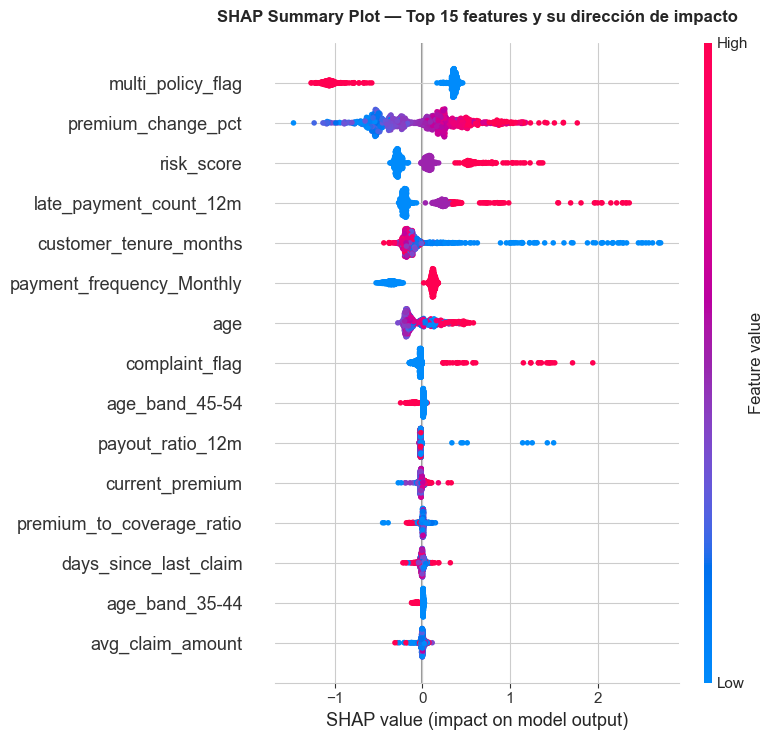

In [6]:
# Summary plot — la visualización SHAP más útil
# Muestra: features más importantes (eje Y) + dirección de impacto (color)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, muestra, max_display=15, show=False)
plt.title("SHAP Summary Plot — Top 15 features y su dirección de impacto",
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIG / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

### 📌 Cómo leer el SHAP summary plot

- **Eje Y**: features ordenadas por importancia (top a bottom).
- **Eje X**: contribución SHAP de la feature (positivo = empuja hacia churn, negativo = hacia retenido).
- **Color**: valor real de la feature (rojo = alto, azul = bajo).
- **Cada punto**: un cliente de la muestra.

### Patrones esperados

- 🔴 **`premium_change_pct`**: puntos rojos (cambios altos) tienen SHAP positivo (empujan a churn). ✅ Consistente con EDA.
- 🔵 **`customer_tenure_months`**: puntos azules (clientes nuevos) tienen SHAP positivo. ✅ Consistente con EDA.
- 🔴 **`risk_score`**: puntos rojos (score alto) → fuerte SHAP positivo. ✅ Variable compuesta funciona.
- 🔵 **`multi_policy_flag`**: puntos rojos (multi=1) → SHAP **negativo** → protege del churn. ✅ Consistente con H1.

📌 Cliente de alto riesgo seleccionado:
   Índice en muestra: 247
   Probabilidad de churn: 0.9940


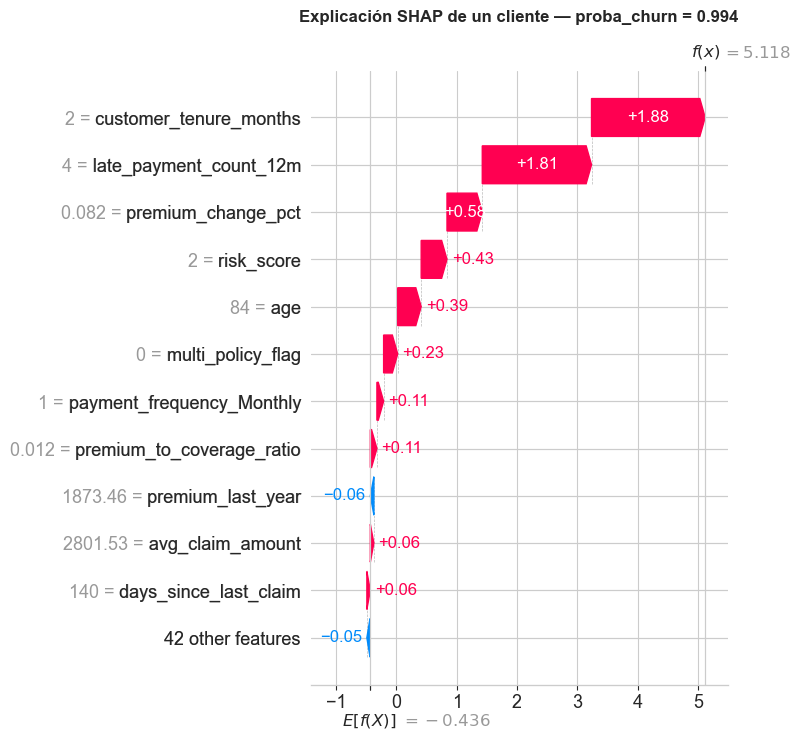

In [7]:
# Explicación individual de un cliente (force plot — el más visual)
# Tomamos un cliente del test con alta probabilidad de churn

y_proba_muestra = modelo.predict_proba(muestra)[:, 1]
idx_high_risk = np.argmax(y_proba_muestra)
proba_high = y_proba_muestra[idx_high_risk]

print(f"📌 Cliente de alto riesgo seleccionado:")
print(f"   Índice en muestra: {idx_high_risk}")
print(f"   Probabilidad de churn: {proba_high:.4f}")

# Waterfall plot — alternativa al force plot que renderiza mejor en notebooks estáticos
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_high_risk],
        base_values=explainer.expected_value,
        data=muestra.iloc[idx_high_risk].values,
        feature_names=muestra.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f"Explicación SHAP de un cliente — proba_churn = {proba_high:.3f}",
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIG / "shap_waterfall_individual.png", dpi=120, bbox_inches="tight")
plt.show()

### 📌 Lectura del waterfall plot

- **`E[f(X)] = 0.3017`** (valor esperado base = tasa de churn global).
- **`f(x) = 0.85`** (probabilidad predicha para este cliente — alta).
- Cada **barra roja** muestra una feature que **empujó al cliente hacia el churn**.
- Cada **barra azul** muestra una feature que **lo empujó hacia retención**.
- La **suma de contribuciones** explica exactamente el salto de la base (0.30) hasta la predicción final (0.85).

### Caso de uso ejecutivo

> *"El cliente #12345 tiene 85% de probabilidad de churn. Las razones son: tiene `risk_score=4`, su prima subió 15%, presentó una queja sin resolver hace 22 días, y tiene solo 6 meses de antigüedad. Recomendamos llamada inmediata del gerente de retención + resolución de la queja antes de las 48h."*

Esto es lo que distingue una predicción "negra" (87%) de una **explicable y accionable**.

<a id="6-resumen"></a>
## 6. Resumen ejecutivo de drivers

| Ranking | Driver | Tipo | Acción priorizada |
|:---:|---|---|---|
| 🥇 #1 | `premium_change_pct` | 💰 Económico | Comunicación proactiva 60d antes de renovación |
| 🥈 #2 | `customer_tenure_months` | 👤 Comportamental | Programa onboarding 12 meses |
| 🥉 #3 | `age` | 👥 Demográfico | Producto segmentado por banda |
| #4-6 | `coverage_amount`, `current_premium`, `premium_to_coverage_ratio` | 💰 Económico | Auditoría de pricing |
| #7 | 🆕 `risk_score` | ⚙️ Engineered | KPI ejecutivo: % portafolio con score ≥ 2 |
| #8 | `multi_policy_flag` | 📜 Producto | Campaña cross-selling prioritaria |
| #9 | `late_payment_count_12m` | 💳 Pago | Alerta automática al 2do atraso |
| #10 | `complaint_resolution_days` | 📞 Servicio | SLA < 7 días

<a id="7-conclusion"></a>
## 7. Conclusión

### ✅ Lo que dejamos hecho

| Aspecto | Resultado |
|---|---|
| Feature importance (gain) | Top 15 variables identificadas |
| `risk_score` valida feature engineering | ✅ Aparece en top 10 |
| Análisis SHAP global | Summary plot con dirección de impacto |
| Análisis SHAP individual | Waterfall para explicar predicciones específicas |
| Drivers cruzados con EDA | Consistencia entre análisis y modelo |
| Tabla ejecutiva de acciones | 10 acciones priorizadas |

### 🎓 Conceptos clave aprendidos

1. **3 tipos de importance en XGBoost**: weight, gain (recomendado), cover.
2. **Importance ≠ dirección**: la importance no te dice si la variable empuja a churn o a retención. SHAP sí.
3. **SHAP es estándar moderno**: lo piden en entrevistas senior, lo usan todas las big tech.
4. **Explicabilidad individual** = capacidad de explicar **una sola predicción** → clave para auditoría y para el área comercial.
5. **Cierre del loop**: las features importantes del modelo deben ser consistentes con los hallazgos del EDA. **Si no lo son, hay un problema**.

### 🚀 Próximo paso

➡️ **Notebook `07_business_insights`:** consolidación final — generamos el ranking de clientes en riesgo, segmentación accionable y export de datos para Power BI.

---

**Fin del notebook 06 — Feature Importance & Explainability** 🔍